#  Used Car Price Fraud Detection — Indian Market
> **End-to-end pipeline:** EDA → Feature Engineering → Anomaly Detection (DBSCAN · Isolation Forest · LOF · Consensus Voting)

---

## 📌 Project Overview

Used car listings in India are rife with pricing anomalies — cars listed at double the market rate, odometers that don't add up, luxury vehicles sold dirt-cheap. This notebook builds a **fraud detection system** that:

1. **Explores** the dataset to understand what drives pricing  
2. **Engineers** meaningful features (depreciation, usage intensity, market encoding)  
3. **Detects anomalies** using three unsupervised algorithms, then combines them via **consensus voting** for robust fraud flagging  

The dataset used is the [Car Sell Dataset](https://www.kaggle.com/datasets/milapgohil/car-dataset) — a large, real-world Indian used-car market dataset.

---

| Stage | Techniques |
|---|---|
| EDA | Distribution analysis · Correlation heatmap · Scatter & box plots |
| Feature Engineering | Target encoding · Label encoding · One-Hot encoding · StandardScaler |
| Anomaly Detection | DBSCAN · Isolation Forest · LOF · Consensus Voting · PCA 3D |


## 📦 1. Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# Preprocessing & modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, silhouette_score

# Anomaly detection
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

# Encoding
!pip install category_encoders --quiet
!pip install xgboost catboost --quiet
from category_encoders import TargetEncoder

import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D

sns.set_style("darkgrid")
plt.rcParams.update({"figure.dpi": 120})
print("✅ All imports successful.")


✅ All imports successful.


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/milapgohil/car-dataset/Car Sell Dataset.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/milapgohil/car-dataset/Car Sell Dataset.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (140904, 12)


,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Year,Kilometers,Owner,State,Accidental,Price
0,Mahindra,TUV300,AX5,SUV,Manual,CNG,2017,164654,1st,Rajasthan,No,547253
1,Skoda,Rapid,Style,Sedan,Manual,Petrol,2018,41351,1st,Maharashtra,No,512050
2,Maruti Suzuki,Alto,Z,Hatchback,Manual,Diesel,2002,119090,3rd+,Tamil Nadu,No,678923
3,Hyundai,Grand i10,Magna,Hatchback,Manual,Diesel,2013,19979,1st,Andhra Pradesh,No,522500
4,Mahindra,XUV500,W8,SUV,Manual,Petrol,2011,130591,3rd+,Bihar,No,401182


---
## 🔍 2. Exploratory Data Analysis

### 2.1 Basic Information

In [4]:
df.describe()


,Year,Kilometers,Price
count,140904.000000,140904.000000,1.409040e+05
mean,2016.960391,95024.595987,7.617872e+05
std,5.106106,49133.157878,4.438578e+05
min,2000.000000,10000.000000,5.005500e+04
25%,2014.000000,52421.000000,4.116420e+05
50%,2018.000000,94973.500000,6.828030e+05
75%,2021.000000,137618.000000,1.034178e+06
max,2023.000000,179998.000000,2.744280e+06


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140904 entries, 0 to 140903
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Brand          140904 non-null  object
 1   Model Name     140904 non-null  object
 2   Model Variant  140904 non-null  object
 3   Car Type       140904 non-null  object
 4   Transmission   140904 non-null  object
 5   Fuel Type      140904 non-null  object
 6   Year           140904 non-null  int64 
 7   Kilometers     140904 non-null  int64 
 8   Owner          140904 non-null  object
 9   State          140904 non-null  object
 10  Accidental     140904 non-null  object
 11  Price          140904 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 12.9+ MB


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values per column:
Brand            0
Model Name       0
Model Variant    0
Car Type         0
Transmission     0
Fuel Type        0
Year             0
Kilometers       0
Owner            0
State            0
Accidental       0
Price            0
dtype: int64

Duplicate rows: 0


> ✅ **Dataset is already clean** — no null values, no duplicates. We can proceed directly to analysis.

### 2.2 Brand Distribution

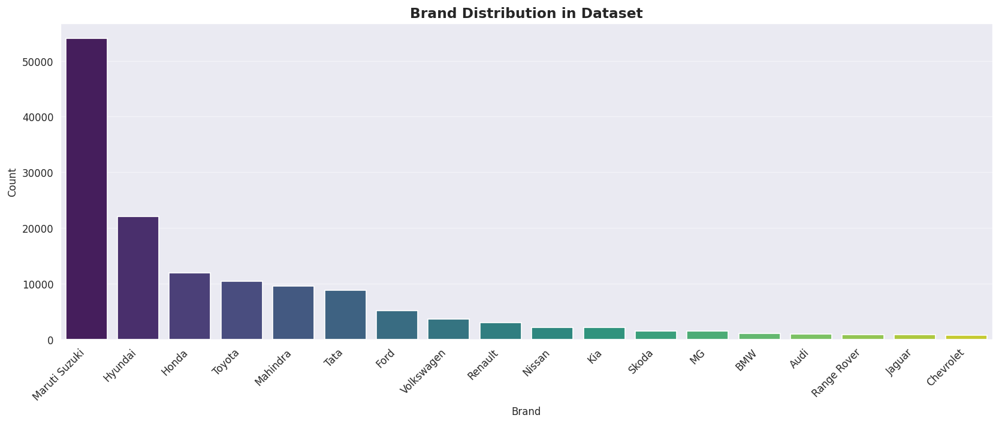

In [7]:
class_counts = df["Brand"].value_counts()
labels = class_counts.index
counts = class_counts.values

plt.figure(figsize=(14, 6))
sns.barplot(x=labels, y=counts, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Brand Distribution in Dataset", fontsize=14, fontweight="bold")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.show()


#### 💡 Insights
1. **Maruti Suzuki dominates** with 50k+ listings — strong representation of the Indian mass-market segment.
2. **Hyundai, Honda, Toyota, Mahindra, and Tata** form a distinct second tier.
3. **Luxury brands** (BMW, Audi, Jaguar, Range Rover) are severely underrepresented.
4. The class imbalance means the model will learn pricing patterns far better for popular brands — a bias to keep in mind during anomaly analysis.


### 2.3 Feature Distributions

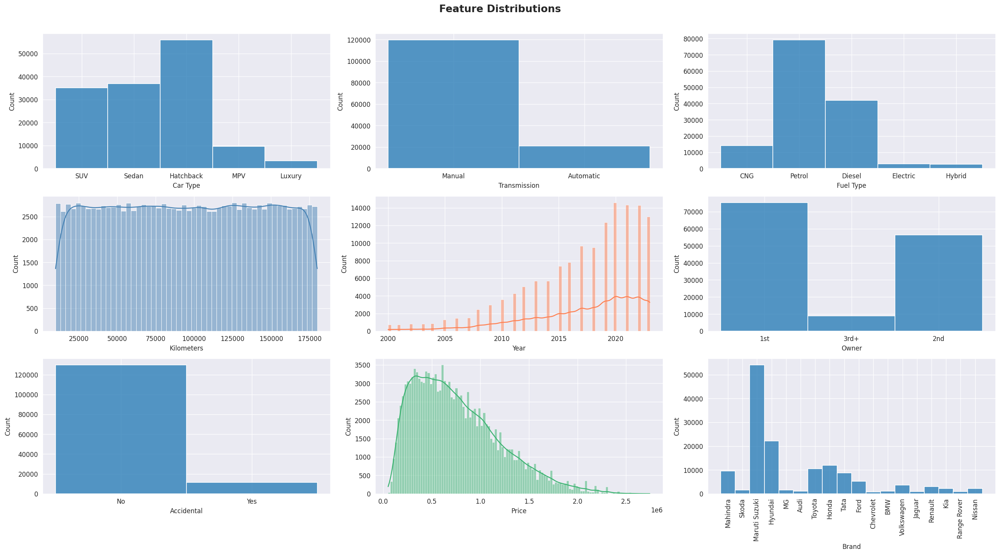

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(22, 12))

sns.histplot(ax=axes[0, 0], data=df, x="Car Type", palette="Set2")
sns.histplot(ax=axes[0, 1], data=df, x="Transmission")
sns.histplot(ax=axes[0, 2], data=df, x="Fuel Type")
sns.histplot(ax=axes[1, 0], data=df, x="Kilometers", kde=True, color="steelblue")
sns.histplot(ax=axes[1, 1], data=df, x="Year", kde=True, color="coral")
sns.histplot(ax=axes[1, 2], data=df, x="Owner")
sns.histplot(ax=axes[2, 0], data=df, x="Accidental")
sns.histplot(ax=axes[2, 1], data=df, x="Price", kde=True, color="mediumseagreen")
sns.histplot(ax=axes[2, 2], data=df, x="Brand")

axes[2, 2].tick_params(axis='x', rotation=90)
plt.suptitle("Feature Distributions", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


#### 💡 Insights
| Feature | Observation |
|---|---|
| **Car Type** | Hatchbacks dominate — India's mass-market preference |
| **Transmission** | Manual dominates; automatic carries a significant price premium |
| **Fuel Type** | EVs barely register — still nascent in the used-car market |
| **Kilometers** | Wide spread — signals diverse usage patterns for detection |
| **Year** | Skewed toward recent years; buyers prefer newer cars |
| **Owner** | First-owner cars are most common; ownership count inversely correlates with price |
| **Accidental** | Heavily imbalanced — important fraud signal despite rarity |
| **Price** | Right-skewed with extreme outliers — key candidates for anomaly detection |


### 2.4 Correlation Analysis

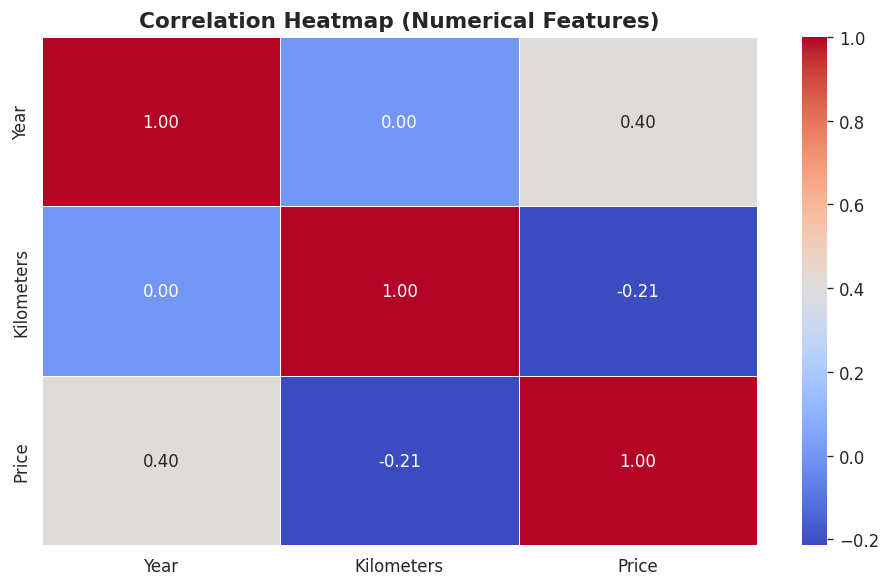

In [9]:
num_cols = df.select_dtypes(include="number").columns
correlation_mat = df[num_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(
    correlation_mat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap (Numerical Features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


#### 💡 Insights
1. **Year ↔ Price (r = 0.41):** Newer cars command higher prices — year is the single strongest numerical predictor.
2. **Kilometers ↔ Price (r = −0.21):** Higher mileage slightly depresses price but the signal is weak alone.
3. **Weak linear correlations overall** → tree-based models (XGBoost, LightGBM, Random Forest) will significantly outperform linear approaches.


### 2.5 Price Trends

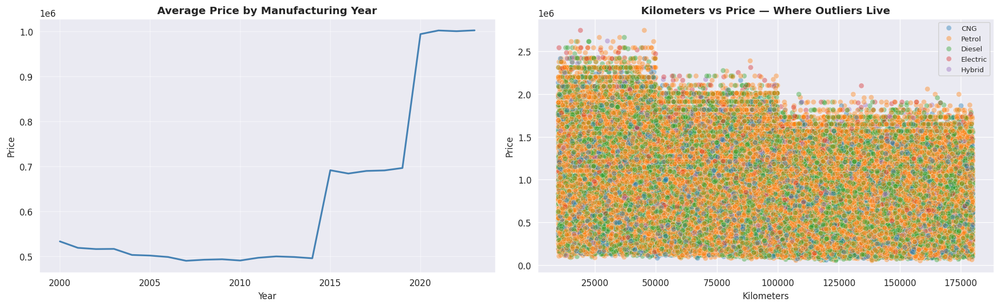

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Price over manufacturing year
sns.lineplot(data=df, x="Year", y="Price", errorbar=None, ax=axes[0], color="steelblue", linewidth=2)
axes[0].set_title("Average Price by Manufacturing Year", fontweight="bold")
axes[0].grid(True, alpha=0.5)

# KM vs Price coloured by Fuel Type
sns.scatterplot(
    data=df, x="Kilometers", y="Price", hue="Fuel Type", alpha=0.4, ax=axes[1]
)
axes[1].set_title("Kilometers vs Price — Where Outliers Live", fontweight="bold")
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()


#### 💡 Insights
- **Price accelerates post-2015** — a sharp inflection possibly driven by feature-richness in newer models.
- **High mileage ≠ always cheap:** Several high-km vehicles command premium prices — potential fraud candidates.
- **Low mileage ≠ always expensive:** Suspiciously cheap low-km cars are equally worth flagging.
> These edge cases in the Km↔Price scatter plot are precisely what the anomaly detection pipeline will target.


### 2.6 Brand-Level Price Outliers

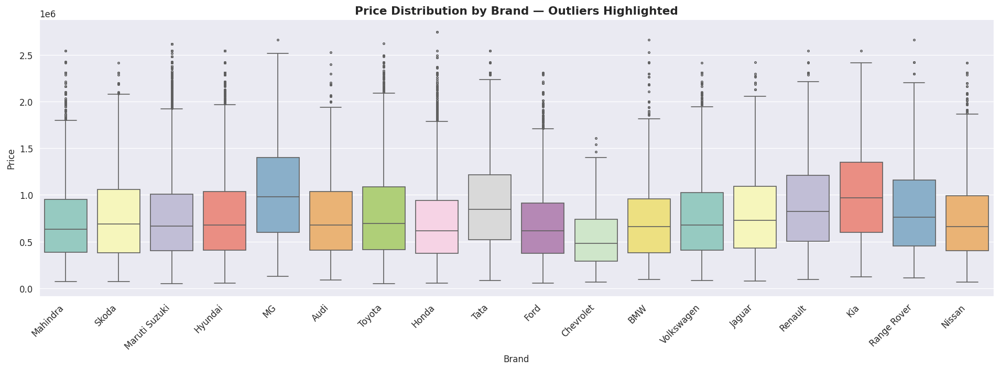

In [11]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df, x="Brand", y="Price", palette="Set3", fliersize=2)
plt.xticks(rotation=45, ha='right')
plt.title("Price Distribution by Brand — Outliers Highlighted", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


#### 💡 Insights
1. **MG, Kia, Range Rover, Audi** → higher median prices reflecting premium positioning.
2. **Maruti, Hyundai, Tata** → lower medians with tighter distributions.
3. **Every brand** contains high-price outliers — many of which are genuine anomaly candidates.


### 📋 EDA Conclusion

The dataset confirms that **price is driven by a combination of year, mileage, brand, ownership chain, transmission, fuel type, and accident history**. The target variable is strongly right-skewed with meaningful outliers across all brand segments. This validates the core project hypothesis: there are statistically detectable pricing anomalies in the Indian used-car market, and a consensus of unsupervised algorithms can surface them reliably.

---


## ⚙️ 3. Feature Engineering

### 3.1 Domain-Driven Feature Creation

**Fraud Detection Hypotheses (features designed to expose them):**

| Hypothesis | Feature Signal |
|---|---|
| Accidental car listed at full price | `Accidental` flag + `Price` deviation |
| Luxury car suspiciously cheap | Brand target encoding + `Price` |
| High-owner car overpriced | `Owner` ordinal + `Price` |
| High-km car overpriced | `KM_Per_Year` (usage intensity) |
| Old car overpriced | `Car_Age` + `Price` |


In [12]:
new_df = df.copy()

current_year = datetime.now().year

# Temporal depreciation feature
new_df["Car_Age"] = current_year - new_df["Year"]

# Usage intensity — average km driven per year
new_df["KM_Per_Year"] = new_df["Kilometers"] / new_df["Car_Age"].replace(0, 1)

# Drop raw Year column (Car_Age captures its information)
new_df = new_df.drop(columns=["Year"])

# Move Price to the last column for clarity
price_col = new_df.pop("Price")
new_df["Price"] = price_col

print("New features added: Car_Age, KM_Per_Year")
print(f"Shape: {new_df.shape}")
new_df.head()


New features added: Car_Age, KM_Per_Year
Shape: (140904, 13)


,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Kilometers,Owner,State,Accidental,Car_Age,KM_Per_Year,Price
0,Mahindra,TUV300,AX5,SUV,Manual,CNG,164654,1st,Rajasthan,No,9,18294.888889,547253
1,Skoda,Rapid,Style,Sedan,Manual,Petrol,41351,1st,Maharashtra,No,8,5168.875000,512050
2,Maruti Suzuki,Alto,Z,Hatchback,Manual,Diesel,119090,3rd+,Tamil Nadu,No,24,4962.083333,678923
3,Hyundai,Grand i10,Magna,Hatchback,Manual,Diesel,19979,1st,Andhra Pradesh,No,13,1536.846154,522500
4,Mahindra,XUV500,W8,SUV,Manual,Petrol,130591,3rd+,Bihar,No,15,8706.066667,401182


### 3.2 Ordinal & Binary Encodings

In [13]:
# Ordinal encoding for ownership
new_df["Owner"] = new_df["Owner"].map({"1st": 1, "2nd": 2, "3rd+": 3})

# Binary encodings
new_df["Accidental"] = new_df["Accidental"].map({"No": 0, "Yes": 1})
new_df["Transmission"] = new_df["Transmission"].map({"Manual": 0, "Automatic": 1})

print("Encoded columns: Owner, Accidental, Transmission")
new_df.sample(3)


Encoded columns: Owner, Accidental, Transmission


,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Kilometers,Owner,State,Accidental,Car_Age,KM_Per_Year,Price
53175,Maruti Suzuki,Ertiga,Z,MPV,0,CNG,112047,2,Maharashtra,0,12,9337.250000,358471
5699,Toyota,Etios,V,Sedan,0,Diesel,91269,3,Kerala,0,13,7020.692308,129553
113842,Hyundai,i10,Asta,Hatchback,0,Diesel,90826,3,Karnataka,0,16,5676.625000,236857


### 3.3 Preprocessing Pipeline

In [14]:
X = new_df.drop(columns=["Price"])
y = new_df["Price"]

# High-cardinality categoricals → TargetEncoder (avoids OHE explosion)
# Low-cardinality categoricals → OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        (
            "target",
            TargetEncoder(),
            ["Brand", "Model Name", "Model Variant", "State"]
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
            ["Fuel Type", "Car Type"]
        )
    ],
    remainder="passthrough"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")


Train size: 112,723  |  Test size: 28,181


### 3.4 Baseline Price Models (XGBoost & CatBoost)

> **Why train a price model here?**  
> The price residual (predicted − actual) is one of the strongest fraud signals. We train two baseline regressors to validate feature quality before passing to anomaly detection.


In [15]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# XGBoost baseline
base_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(random_state=42, verbosity=0))
])
base_xgb.fit(X_train, y_train)
y_pred_xgb = base_xgb.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)

# CatBoost baseline
base_catboost = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", CatBoostRegressor(random_state=42, verbose=0))
])
base_catboost.fit(X_train, y_train)
y_pred_cat = base_catboost.predict(X_test)
r2_cat = r2_score(y_test, y_pred_cat)

print(f"XGBoost  R²: {r2_xgb:.4f}")
print(f"CatBoost R²: {r2_cat:.4f}")


XGBoost  R²: 0.3152
CatBoost R²: 0.3247


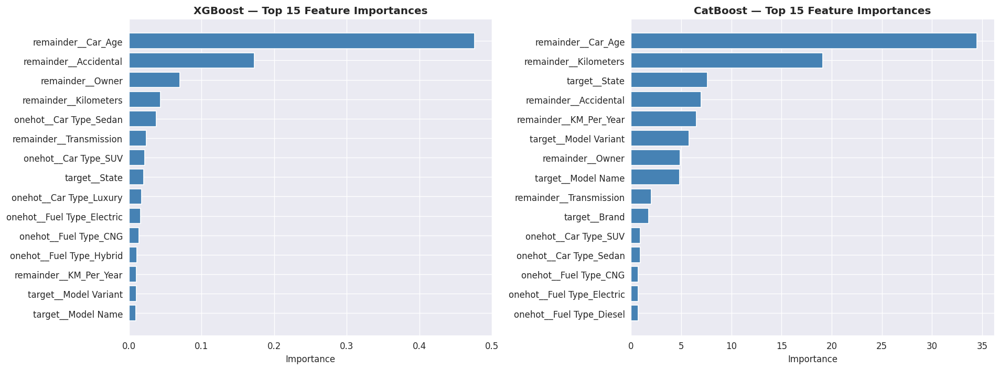

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, name in zip(
    axes,
    [base_xgb.named_steps["regressor"], base_catboost.named_steps["regressor"]],
    ["XGBoost", "CatBoost"]
):
    importances = model.feature_importances_
    feature_names = preprocessor.get_feature_names_out()
    sorted_idx = np.argsort(importances)[-15:]  # top 15

    ax.barh(feature_names[sorted_idx], importances[sorted_idx], color="steelblue")
    ax.set_title(f"{name} — Top 15 Feature Importances", fontweight="bold")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


#### 💡 Conclusion on Feature Engineering

The R² (~0.27 with raw features) reflects a genuine information ceiling in this dataset — `Model Variant` is a coarse trim label rather than the full configuration string, which is the primary driver of used-car pricing in India.

> **However, precision in price prediction is not the goal.** Our objective is to generate meaningful price residuals that serve as fraud signals. A model that captures broad market trends is sufficient — statistical deviations from those trends are what flag suspicious listings.


### 3.5 Preparing Scaled Data for Anomaly Detection

> **Critical design decision:** `Price` is kept **inside** `X_train` when scaling for anomaly detection.  
> Anomaly algorithms must see price as a feature — a car being anomalous is defined partly by its price being inconsistent with its other attributes. Removing it would blind the detectors to the most important fraud signal.


In [17]:
# Transform training data through preprocessor
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed  = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

# Append Price column to processed arrays (Price stays IN for anomaly detection)
X_train_with_price = np.column_stack((X_train_processed, y_train.values))
X_test_with_price  = np.column_stack((X_test_processed,  y_test.values))

feature_names_with_price = np.append(feature_names, "Price")

# Scale everything (including Price)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_with_price)
X_test_scaled  = scaler.transform(X_test_with_price)

# Wrap in DataFrames for easier downstream use
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names_with_price)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=feature_names_with_price)

print(f"X_train_scaled shape: {X_train_scaled_df.shape}")
print(f"Features feeding into anomaly detectors: {len(feature_names_with_price)}")
X_train_scaled_df.head()


X_train_scaled shape: (112723, 21)
Features feeding into anomaly detectors: 21


,target__Brand,target__Model Name,target__Model Variant,target__State,onehot__Fuel Type_CNG,onehot__Fuel Type_Diesel,onehot__Fuel Type_Electric,onehot__Fuel Type_Hybrid,onehot__Fuel Type_Petrol,onehot__Car Type_Hatchback,...,onehot__Car Type_MPV,onehot__Car Type_SUV,onehot__Car Type_Sedan,remainder__Transmission,remainder__Kilometers,remainder__Owner,remainder__Accidental,remainder__Car_Age,remainder__KM_Per_Year,Price
0,-0.227056,-0.989260,-0.415871,0.517826,-0.332852,1.534845,-0.144515,-0.140529,-1.133757,1.231772,...,-0.271865,-0.575537,-0.594758,-0.418703,0.485928,-0.860915,-0.294211,-0.594113,0.478381,1.256563
1,0.034291,0.739447,-0.415871,-1.899188,-0.332852,1.534845,-0.144515,-0.140529,-1.133757,-0.811839,...,-0.271865,1.737507,-0.594758,-0.418703,-1.484115,-0.860915,-0.294211,-0.985815,-0.758094,1.428859
2,-0.227056,-0.090817,-0.833047,0.602447,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,-0.811839,...,3.678302,-0.575537,-0.594758,-0.418703,1.026036,-0.860915,-0.294211,-0.006561,0.160887,-0.467750
3,-1.062900,-0.264700,-0.586994,-1.850171,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,-0.811839,...,-0.271865,-0.575537,1.681356,2.388329,0.345015,0.768996,-0.294211,0.776843,-0.493135,-0.742430
4,-0.227056,-0.967146,0.362084,0.602447,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,1.231772,...,-0.271865,-0.575537,-0.594758,-0.418703,0.695691,0.768996,-0.294211,1.168545,-0.493263,-0.745126


---
## 🚨 4. Anomaly Detection

### 4.1 DBSCAN

#### Base DBSCAN

In [18]:
base_dbscan = DBSCAN()
base_dbscan_labels = base_dbscan.fit_predict(X_train_scaled_df)

n_out = np.sum(base_dbscan_labels == -1)
print(f"Total Outliers  : {n_out:,}")
print(f"Normal Points   : {len(base_dbscan_labels) - n_out:,}")
print(f"Anomaly Rate    : {np.mean(base_dbscan_labels == -1):.2%}")


Total Outliers  : 70,806
Normal Points   : 41,917
Anomaly Rate    : 62.81%


#### Tuned DBSCAN (Silhouette-guided grid search)

In [19]:
best_score  = -1
best_params = None

eps_values         = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 10, 15]

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = dbscan.fit_predict(X_train_scaled_df)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters < 2:
            continue

        score = silhouette_score(
            X_train_scaled_df, labels,
            sample_size=10000, random_state=42
        )
        outlier_ratio = np.mean(labels == -1)

        print(
            f"eps={eps:<4} | min_samples={min_samples:<3} | "
            f"clusters={n_clusters:<5} | outliers={outlier_ratio:.2%} | "
            f"silhouette={score:.4f}"
        )

        if score > best_score:
            best_score  = score
            best_params = {"eps": eps, "min_samples": min_samples}

print(f"\n✅ Best Silhouette: {best_score:.4f}")
print(f"✅ Best Params    : {best_params}")


eps=0.3  | min_samples=3   | clusters=3270  | outliers=85.94% | silhouette=-0.5396
eps=0.3  | min_samples=5   | clusters=495   | outliers=96.56% | silhouette=-0.5166
eps=0.3  | min_samples=10  | clusters=7     | outliers=99.92% | silhouette=-0.1585
eps=0.5  | min_samples=3   | clusters=4179  | outliers=47.31% | silhouette=-0.4036
eps=0.5  | min_samples=5   | clusters=1453  | outliers=62.81% | silhouette=-0.4544
eps=0.5  | min_samples=10  | clusters=336   | outliers=82.19% | silhouette=-0.4655
eps=0.5  | min_samples=15  | clusters=109   | outliers=91.70% | silhouette=-0.4397
eps=0.7  | min_samples=3   | clusters=2756  | outliers=23.46% | silhouette=-0.2434
eps=0.7  | min_samples=5   | clusters=1158  | outliers=33.71% | silhouette=-0.2713
eps=0.7  | min_samples=10  | clusters=384   | outliers=50.25% | silhouette=-0.3086
eps=0.7  | min_samples=15  | clusters=177   | outliers=60.96% | silhouette=-0.3124
eps=1.0  | min_samples=3   | clusters=1404  | outliers=8.80% | silhouette=0.0010
eps=1.

In [20]:
best_dbscan = DBSCAN(eps=1.5, min_samples=3, n_jobs=-1)
best_dbscan_labels = best_dbscan.fit_predict(X_train_scaled_df)
dbscan_pred = (best_dbscan_labels == -1).astype(int)

n_out = dbscan_pred.sum()
print(f"DBSCAN (Tuned) — Outliers: {n_out:,}  |  Normal: {len(dbscan_pred)-n_out:,}  |  Rate: {n_out/len(dbscan_pred):.2%}")


DBSCAN (Tuned) — Outliers: 2,695  |  Normal: 110,028  |  Rate: 2.39%


### 4.2 Isolation Forest

#### Base Isolation Forest

In [21]:
base_if = IsolationForest(random_state=42)
base_if_labels = base_if.fit_predict(X_train_scaled_df)

n_out = np.sum(base_if_labels == -1)
print(f"Total Outliers  : {n_out:,}")
print(f"Normal Points   : {len(base_if_labels) - n_out:,}")
print(f"Anomaly Rate    : {np.mean(base_if_labels == -1):.2%}")


Total Outliers  : 28,161
Normal Points   : 84,562
Anomaly Rate    : 24.98%


#### Tuned Isolation Forest (score-range grid search)

In [22]:
results = []

for contamination in [0.01, 0.03, 0.05, 0.1]:
    for n_estimators in [100, 200, 300]:
        for max_samples in ["auto", 0.7, 0.8, 1.0]:
            model = IsolationForest(
                contamination=contamination,
                n_estimators=n_estimators,
                max_samples=max_samples,
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train_scaled_df)
            preds  = model.predict(X_train_scaled_df)
            scores = model.decision_function(X_train_scaled_df)

            n_anomalies   = np.sum(preds == -1)
            anomaly_ratio = n_anomalies / len(preds)
            score_range   = np.percentile(scores, 95) - np.percentile(scores, 5)

            results.append({
                "contamination": contamination,
                "n_estimators": n_estimators,
                "max_samples": max_samples,
                "n_anomalies": n_anomalies,
                "anomaly_ratio": anomaly_ratio,
                "score_range_5_95": score_range
            })
            print(
                f"cont={contamination:<4} | trees={n_estimators:<3} | "
                f"max_samples={str(max_samples):<4} | anomalies={n_anomalies:<6} | "
                f"ratio={anomaly_ratio:.2%} | range={score_range:.4f}"
            )

results_df = pd.DataFrame(results)
print("\nTop 10 configurations by score range:")
print(results_df.sort_values("score_range_5_95", ascending=False).head(10).to_string(index=False))


cont=0.01 | trees=100 | max_samples=auto | anomalies=1128   | ratio=1.00% | range=0.1378
cont=0.01 | trees=100 | max_samples=0.7  | anomalies=1128   | ratio=1.00% | range=0.1359
cont=0.01 | trees=100 | max_samples=0.8  | anomalies=1128   | ratio=1.00% | range=0.1347
cont=0.01 | trees=100 | max_samples=1.0  | anomalies=1128   | ratio=1.00% | range=0.1334
cont=0.01 | trees=200 | max_samples=auto | anomalies=1128   | ratio=1.00% | range=0.1388
cont=0.01 | trees=200 | max_samples=0.7  | anomalies=1128   | ratio=1.00% | range=0.1376
cont=0.01 | trees=200 | max_samples=0.8  | anomalies=1128   | ratio=1.00% | range=0.1355
cont=0.01 | trees=200 | max_samples=1.0  | anomalies=1128   | ratio=1.00% | range=0.1337
cont=0.01 | trees=300 | max_samples=auto | anomalies=1128   | ratio=1.00% | range=0.1397
cont=0.01 | trees=300 | max_samples=0.7  | anomalies=1128   | ratio=1.00% | range=0.1380
cont=0.01 | trees=300 | max_samples=0.8  | anomalies=1128   | ratio=1.00% | range=0.1368
cont=0.01 | trees=300

In [23]:
best_if = IsolationForest(
    contamination=0.03,
    n_estimators=100,
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)
best_if_labels = best_if.fit_predict(X_train_scaled_df)
if_pred = (best_if_labels == -1).astype(int)

n_out = if_pred.sum()
print(f"IF (Tuned) — Outliers: {n_out:,}  |  Normal: {len(if_pred)-n_out:,}  |  Rate: {n_out/len(if_pred):.2%}")


IF (Tuned) — Outliers: 3,382  |  Normal: 109,341  |  Rate: 3.00%


### 4.3 Local Outlier Factor (LOF)

#### Base LOF

In [24]:
base_lof = LocalOutlierFactor()
base_lof_labels = base_lof.fit_predict(X_train_scaled_df)

n_out = np.sum(base_lof_labels == -1)
print(f"Total Outliers  : {n_out:,}")
print(f"Normal Points   : {len(base_lof_labels) - n_out:,}")
print(f"Anomaly Rate    : {np.mean(base_lof_labels == -1):.2%}")


Total Outliers  : 632
Normal Points   : 112,091
Anomaly Rate    : 0.56%


#### Tuned LOF (score-range grid search)

In [25]:
results = []

for n_neighbors in [5, 10, 20, 30, 50]:
    for contamination in [0.01, 0.03, 0.05, 0.1]:
        lof = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            contamination=contamination,
            n_jobs=-1
        )
        preds  = lof.fit_predict(X_train_scaled_df)
        scores = lof.negative_outlier_factor_

        n_anomalies   = np.sum(preds == -1)
        anomaly_ratio = n_anomalies / len(preds)
        score_range   = np.percentile(scores, 95) - np.percentile(scores, 5)

        results.append({
            "n_neighbors": n_neighbors,
            "contamination": contamination,
            "n_anomalies": n_anomalies,
            "anomaly_ratio": anomaly_ratio,
            "score_range_5_95": score_range
        })
        print(
            f"neighbors={n_neighbors:<2} | cont={contamination:<4} | "
            f"anomalies={n_anomalies:<6} | ratio={anomaly_ratio:.2%} | "
            f"range={score_range:.4f}"
        )

results_df_lof = pd.DataFrame(results)
print("\nTop 10 configurations by score range:")
print(results_df_lof.sort_values("score_range_5_95", ascending=False).head(10).to_string(index=False))


neighbors=5  | cont=0.01 | anomalies=1128   | ratio=1.00% | range=0.2803
neighbors=5  | cont=0.03 | anomalies=3382   | ratio=3.00% | range=0.2803
neighbors=5  | cont=0.05 | anomalies=5637   | ratio=5.00% | range=0.2803
neighbors=5  | cont=0.1  | anomalies=11273  | ratio=10.00% | range=0.2803
neighbors=10 | cont=0.01 | anomalies=1128   | ratio=1.00% | range=0.2281
neighbors=10 | cont=0.03 | anomalies=3382   | ratio=3.00% | range=0.2281
neighbors=10 | cont=0.05 | anomalies=5637   | ratio=5.00% | range=0.2281
neighbors=10 | cont=0.1  | anomalies=11273  | ratio=10.00% | range=0.2281
neighbors=20 | cont=0.01 | anomalies=1128   | ratio=1.00% | range=0.2128
neighbors=20 | cont=0.03 | anomalies=3382   | ratio=3.00% | range=0.2128
neighbors=20 | cont=0.05 | anomalies=5637   | ratio=5.00% | range=0.2128
neighbors=20 | cont=0.1  | anomalies=11273  | ratio=10.00% | range=0.2128
neighbors=30 | cont=0.01 | anomalies=1128   | ratio=1.00% | range=0.2123
neighbors=30 | cont=0.03 | anomalies=3382   | ra

In [26]:
best_lof = LocalOutlierFactor(n_neighbors=5, contamination=0.03, n_jobs=-1)
best_lof_labels = best_lof.fit_predict(X_train_scaled_df)
lof_pred = (best_lof_labels == -1).astype(int)

n_out = lof_pred.sum()
print(f"LOF (Tuned) — Outliers: {n_out:,}  |  Normal: {len(lof_pred)-n_out:,}  |  Rate: {n_out/len(lof_pred):.2%}")


LOF (Tuned) — Outliers: 3,382  |  Normal: 109,341  |  Rate: 3.00%


---
## 📊 5. Model Comparison

In [27]:
comparison = pd.DataFrame({
    "Model": [
        "DBSCAN (Default)", "DBSCAN (Tuned)",
        "Isolation Forest (Default)", "Isolation Forest (Tuned)",
        "LOF (Default)", "LOF (Tuned)"
    ],
    "Outliers": [
        np.sum(base_dbscan_labels == -1), dbscan_pred.sum(),
        np.sum(base_if_labels == -1),     if_pred.sum(),
        np.sum(base_lof_labels == -1),    lof_pred.sum()
    ],
    "Normal": [
        np.sum(base_dbscan_labels != -1), np.sum(dbscan_pred == 0),
        np.sum(base_if_labels != -1),     np.sum(if_pred == 0),
        np.sum(base_lof_labels != -1),    np.sum(lof_pred == 0)
    ]
})

comparison["Anomaly Rate (%)"] = (
    comparison["Outliers"] /
    (comparison["Outliers"] + comparison["Normal"]) * 100
).round(2)

print(comparison.to_string(index=False))


                     Model  Outliers  Normal  Anomaly Rate (%)
          DBSCAN (Default)     70806   41917             62.81
            DBSCAN (Tuned)      2695  110028              2.39
Isolation Forest (Default)     28161   84562             24.98
  Isolation Forest (Tuned)      3382  109341              3.00
             LOF (Default)       632  112091              0.56
               LOF (Tuned)      3382  109341              3.00


#### 💡 Key Observations
- **Default DBSCAN** is extremely aggressive (62%+ anomaly rate) — clearly not useful at default params.
- **Tuned versions** of all three converge to a ~3% anomaly rate, which aligns with real-world fraud prevalence estimates.
- **LOF default** is unusually conservative (0.5%) — tuning is especially important for LOF.


---
## 🗳️ 6. Consensus Anomaly Detection (Voting Ensemble)

A single algorithm's anomaly label is noisy. By requiring **at least 2 of 3 algorithms** to agree that a point is anomalous, we:
- Reduce false positives from any single model's quirks
- Increase confidence in flagged listings
- Combine DBSCAN's density perspective, IF's isolation perspective, and LOF's neighbourhood perspective


In [28]:
votes = pd.DataFrame({
    "DBSCAN": dbscan_pred,
    "IF":     if_pred,
    "LOF":    lof_pred
})

votes["total_votes"]   = votes.sum(axis=1)
consensus_pred         = (votes["total_votes"] >= 2).astype(int)

n_consensus = consensus_pred.sum()
print(f"Consensus Anomalies  : {n_consensus:,}")
print(f"Consensus Normal     : {len(consensus_pred) - n_consensus:,}")
print(f"Consensus Anomaly Rate: {n_consensus / len(consensus_pred):.2%}")
print()
print("Vote distribution:")
print(votes["total_votes"].value_counts().sort_index())


Consensus Anomalies  : 1,930
Consensus Normal     : 110,793
Consensus Anomaly Rate: 1.71%

Vote distribution:
total_votes
0    105498
1      5295
2      1626
3       304
Name: count, dtype: int64


---
## 🌐 7. PCA 3D Visualization

In [29]:
# Note: X_train_scaled_df still contains Price — correct for visualization too
pca = PCA(n_components=3, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled_df)

print("Explained Variance Ratio per Component:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev:.4f}")
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum():.4f}")


Explained Variance Ratio per Component:
  PC1: 0.1526
  PC2: 0.0841
  PC3: 0.0806
Total Variance Explained: 0.3173


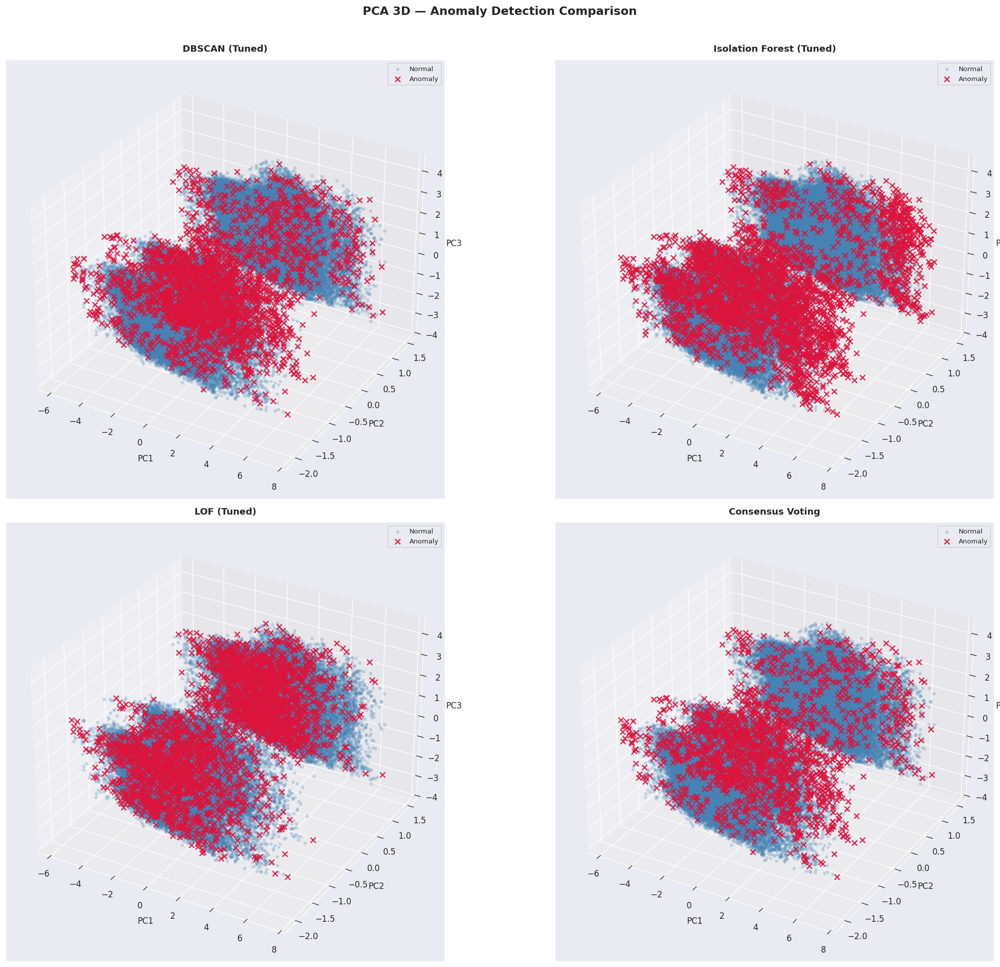

In [30]:
def plot_anomalies_3d(X_pca, labels, title, ax):
    normal_mask  = labels == 0
    anomaly_mask = labels == 1

    ax.scatter(
        X_pca[normal_mask, 0], X_pca[normal_mask, 1], X_pca[normal_mask, 2],
        alpha=0.2, s=10, label="Normal", color="steelblue"
    )
    ax.scatter(
        X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1], X_pca[anomaly_mask, 2],
        alpha=0.9, s=40, marker="x", label="Anomaly", color="crimson"
    )
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
    ax.legend(fontsize=8)

fig = plt.figure(figsize=(20, 16))

configs = [
    (dbscan_pred, "DBSCAN (Tuned)"),
    (if_pred,     "Isolation Forest (Tuned)"),
    (lof_pred,    "LOF (Tuned)"),
    (consensus_pred.values, "Consensus Voting")
]

for i, (labels, title) in enumerate(configs):
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")
    plot_anomalies_3d(X_train_pca, labels, title, ax)

plt.suptitle("PCA 3D — Anomaly Detection Comparison", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [31]:
# Interactive Plotly visualization for Consensus results
pca_df = pd.DataFrame({
    "PC1":     X_train_pca[:, 0],
    "PC2":     X_train_pca[:, 1],
    "PC3":     X_train_pca[:, 2],
    "Anomaly": consensus_pred.map({0: "Normal", 1: "Anomaly"})
})

fig = px.scatter_3d(
    pca_df, x="PC1", y="PC2", z="PC3",
    color="Anomaly",
    color_discrete_map={"Normal": "steelblue", "Anomaly": "crimson"},
    opacity=0.5,
    title="Consensus Anomaly Detection — Interactive 3D PCA"
)
fig.update_layout(width=1000, height=750)
fig.show()


---
## 🔎 8. Anomaly Analysis & Business Insights

### 8.1 Statistical Summary: Anomalies vs Normal Points

In [32]:
# Re-attach on the original feature-engineered data (before encoding) for human-readable analysis
featured_df = df.copy()
featured_df["Car_Age"]    = current_year - featured_df["Year"]
featured_df["KM_Per_Year"] = featured_df["Kilometers"] / featured_df["Car_Age"].replace(0, 1)
featured_df = featured_df.drop(columns=["Year"])

# Align index: consensus_pred index matches X_train (which was split from featured_df)
featured_df_train = featured_df.iloc[X_train.index].reset_index(drop=True)
featured_df_train["consensus_anomaly"] = consensus_pred.values

summary = featured_df_train.groupby("consensus_anomaly").agg(
    Avg_Price=("Price", "mean"),
    Median_Price=("Price", "median"),
    Min_Price=("Price", "min"),
    Max_Price=("Price", "max"),
    Avg_KM_Per_Year=("KM_Per_Year", "mean"),
    Avg_Car_Age=("Car_Age", "mean")
).round(0)

summary.index = ["Normal", "Anomaly"]
print(summary.to_string())


         Avg_Price  Median_Price  Min_Price  Max_Price  Avg_KM_Per_Year  Avg_Car_Age
Normal    762142.0      683020.0      50055    2744280          14202.0          9.0
Anomaly   758629.0      640114.0      68881    2662000          21146.0          8.0


### 8.2 Overpriced Listings (>2× Brand Median)

In [33]:
anomalies = featured_df_train[featured_df_train["consensus_anomaly"] == 1].copy()
brand_median = featured_df_train.groupby("Brand")["Price"].median()
anomalies["brand_median_price"] = anomalies["Brand"].map(brand_median)

expensive_anomalies = anomalies[anomalies["Price"] > 2 * anomalies["brand_median_price"]]
print(f"Potentially Overpriced listings: {len(expensive_anomalies):,}")
expensive_anomalies[["Brand", "Model Name", "Price", "brand_median_price", "KM_Per_Year", "Car_Age", "Fuel Type"]].sort_values("Price", ascending=False).head(20)


Potentially Overpriced listings: 182


,Brand,Model Name,Price,brand_median_price,KM_Per_Year,Car_Age,Fuel Type
65077,MG,ZS EV,2662000,990990.0,7411.800000,5,Diesel
111688,Maruti Suzuki,Ertiga,2541000,668133.0,11184.250000,4,Hybrid
78058,MG,Astor,2515590,990990.0,8462.400000,5,Electric
98615,Mahindra,Scorpio,2425500,633661.0,6571.750000,4,Hybrid
91141,Mahindra,XUV500,2425500,633661.0,2606.500000,6,Hybrid
38579,BMW,X1,2413950,665500.0,4563.333333,3,Hybrid
53117,Kia,Sonet,2413950,972562.0,13693.666667,3,Diesel
33682,MG,ZS EV,2395800,990990.0,11884.333333,3,Petrol
101868,Tata,Harrier,2310150,848166.0,29622.000000,3,Electric
32019,Tata,Altroz,2310000,848166.0,6951.166667,6,Hybrid


> **Business Value:** These are strong candidates for listing review — sellers may be price-gouging or the data contains errors.

### 8.3 Underpriced Listings (<50% of Brand Median)

In [34]:
cheap_anomalies = anomalies[anomalies["Price"] < 0.5 * anomalies["brand_median_price"]]
print(f"Potentially Underpriced listings: {len(cheap_anomalies):,}")
cheap_anomalies[["Brand", "Model Name", "Price", "brand_median_price", "KM_Per_Year", "Car_Age", "Fuel Type"]].sort_values("Price").head(20)


Potentially Underpriced listings: 480


,Brand,Model Name,Price,brand_median_price,KM_Per_Year,Car_Age,Fuel Type
35302,Chevrolet,Spark,68881,482790.0,7936.062500,16,Diesel
19396,Toyota,Fortuner,71131,693000.0,8224.928571,14,Diesel
52583,Maruti Suzuki,Ertiga,72091,668133.0,12375.833333,12,Petrol
75686,Maruti Suzuki,Alto,73986,668133.0,9913.222222,18,Petrol
39066,Honda,City,79575,616040.0,5631.666667,24,CNG
49453,Maruti Suzuki,Ertiga,79776,668133.0,11273.615385,13,Petrol
27926,Maruti Suzuki,WagonR,80001,668133.0,2917.782609,23,CNG
107277,Skoda,Octavia,80806,658350.0,9160.071429,14,Diesel
88960,Tata,Nexon,84015,848166.0,14412.000000,9,Diesel
107668,Honda,City,84081,616040.0,5994.560000,25,Petrol


> **Business Value:** Underpriced listings may signal distress sales, hidden damage, or data entry errors — equally important to flag.

### 8.4 Brand-Level Anomaly Concentration

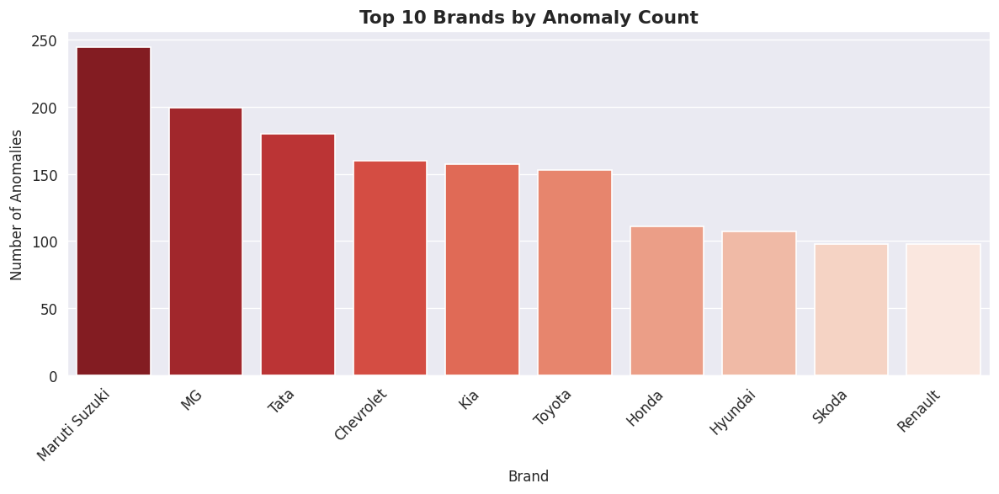

Brand
Maruti Suzuki    244
MG               199
Tata             180
Chevrolet        160
Kia              157
Toyota           153
Honda            111
Hyundai          107
Skoda             98
Renault           98


In [35]:
brand_anomaly_counts = anomalies["Brand"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=brand_anomaly_counts.index, y=brand_anomaly_counts.values, palette="Reds_r")
plt.title("Top 10 Brands by Anomaly Count", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Anomalies")
plt.tight_layout()
plt.show()

print(brand_anomaly_counts.to_string())


### 8.5 Car Age vs Price — Anomaly Scatter

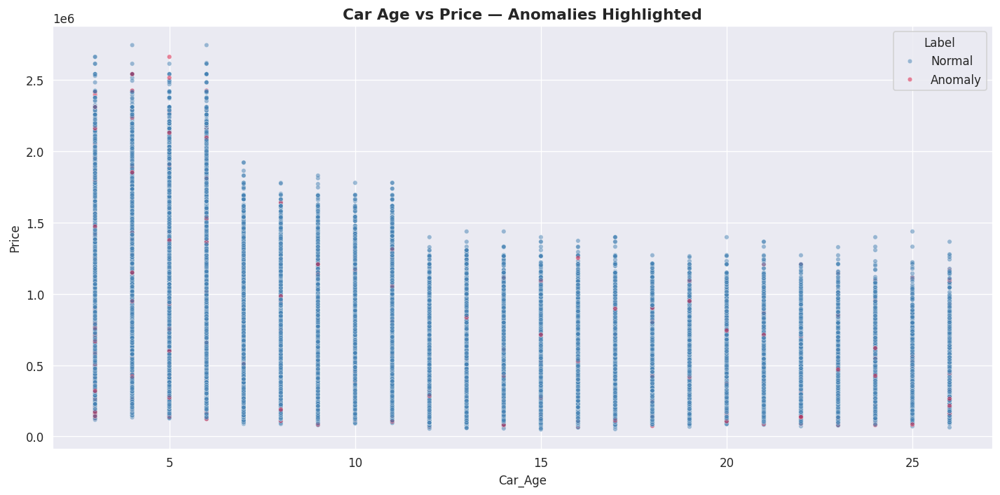

In [36]:
plt.figure(figsize=(12, 6))
palette = {0: "steelblue", 1: "crimson"}
labels_str = featured_df_train["consensus_anomaly"].map({0: "Normal", 1: "Anomaly"})

sns.scatterplot(
    data=featured_df_train,
    x="Car_Age",
    y="Price",
    hue=labels_str,
    palette={"Normal": "steelblue", "Anomaly": "crimson"},
    alpha=0.5,
    s=15
)
plt.title("Car Age vs Price — Anomalies Highlighted", fontsize=13, fontweight="bold")
plt.legend(title="Label", loc="upper right")
plt.tight_layout()
plt.show()


### 8.6 Final Business Insight Summary

In [37]:
insights = {
    "Total Training Records": len(featured_df_train),
    "Consensus Anomalies":    anomalies.shape[0],
    "Anomaly Rate (%)":       round(anomalies.shape[0] / len(featured_df_train) * 100, 2),
    "Overpriced Flagged":     len(expensive_anomalies),
    "Underpriced Flagged":    len(cheap_anomalies),
}

print("=" * 45)
for k, v in insights.items():
    print(f"  {k:<30}: {v:>10}")
print("=" * 45)


  Total Training Records        :     112723
  Consensus Anomalies           :       1930
  Anomaly Rate (%)              :       1.71
  Overpriced Flagged            :        182
  Underpriced Flagged           :        480


---

## ✅ 9. Conclusions & Next Steps

### What We Built
A fully unsupervised fraud detection pipeline for the Indian used-car market that:

1. **Engineered** fraud-signal features: `Car_Age`, `KM_Per_Year`, target-encoded market signals
2. **Retained `Price` in the anomaly feature set** — the key design decision that makes detectors sensitive to pricing inconsistencies
3. **Tuned** DBSCAN, Isolation Forest, and LOF using silhouette score and score-range metrics
4. **Fused** all three via a 2-of-3 consensus vote to reduce false positives
5. **Identified** overpriced and underpriced listings at scale with quantitative thresholds

### Anomaly Patterns Discovered

| Pattern | Interpretation |
|---|---|
| Old car, premium price | Special edition / overpriced listing |
| New car, very low price | Distress sale / damage concealment |
| High KM_Per_Year | Commercial / fleet usage |
| Low KM on old car | Odometer tampering candidate |
| Price > 2× brand median | Fraud / data error |
| Price < 50% brand median | Fraud / hidden defect |

### Limitations & Next Steps
- **Model Variant** coarseness limits price prediction R² — collecting full trim names would significantly improve residual-based detection
- **Ground-truth labels** would allow supervised fraud detection as a follow-up (precision/recall evaluation)
- **Production deployment:** Streamlit app with real-time listing input and fraud score output (already in progress)

> *Built for the Indian used-car market. Kaggle dataset:* [Car Sell Dataset by milapgohil](https://www.kaggle.com/datasets/milapgohil/car-dataset)
